<a href="https://colab.research.google.com/github/diogokelmer/MVP2_Trabalho/blob/main/MVP_ML_%26_Analytics_Diogo_Kelmer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Template — MVP: *Machine Learning & Analytics*
**Autor:** Diogo Kelmer

**Data:** 28/09/2025

**Matrícula:** 4052025000826

**Dataset:** [Insurance Dataset](https://www.kaggle.com/datasets/mirichoi0218/insurance)

# 1. Escopo, objetivo e definição do problema

Contexto e objetivo
O conjunto de dados contém informações de clientes de seguro de saúde, com variáveis demográficas (idade, sexo, número de filhos), características de estilo de vida (IMC, hábito de fumar) e região de residência. O objetivo deste trabalho é prever o custo do seguro de saúde (charges) a partir dessas variáveis, construindo um modelo de regressão que estime o valor esperado do seguro para um novo cliente.

Tipo de tarefa
Regressão supervisionada: a variável alvo é contínua e o problema consiste em prever um valor numérico.

Área de aplicação
Dados tabulares aplicado ao setor de seguros e saúde. O trabalho envolve etapas de limpeza, engenharia de atributos, modelagem e avaliação de modelos de regressão.

### Valor para o negócio e para o usuário

- Permite à seguradora melhorar a precificação de apólices, reduzindo risco financeiro e sub ou super precificação.

- Suporta decisões comerciais, por exemplo, identificação de subgrupos com custos esperados mais altos para campanhas de prevenção ou políticas de subsídio.

- Oferece transparência aos clientes sobre os principais fatores que impactam o custo do seguro, podendo orientar ações de prevenção e redução de risco.

### Escopo do MVP

- Preparação dos dados e engenharia de atributos a partir do CSV fornecido.

- Implementação de um baseline simples (média e regressão linear).

- Treino e comparação de modelos (ex.: regressão regularizada, Random Forest, Gradient Boosting).

- Otimização de hiperparâmetros e avaliação com métricas adequadas (MAE, RMSE, R²).

- Documentação das decisões, seeds para reprodutibilidade e relatório das limitações e próximos passos.

# 2. Reprodutibilidade e ambiente

Para garantir reprodutibilidade, foram utilizadas bibliotecas consolidadas do ecossistema Python para ciência de dados e aprendizado de máquina. Além disso, definiu-se uma semente fixa para os geradores de números aleatórios, de forma a manter consistência nos resultados.

**Bibliotecas utilizadas**
- `numpy` e `pandas` para manipulação e análise de dados.
- `matplotlib` e `seaborn` para visualização.
- `scikit-learn` para pré-processamento, modelagem, validação e métricas.
- `scipy` para distribuições usadas em busca de hiperparâmetros.

**Reprodutibilidade**
- Definição de `SEED = 42` aplicada em `numpy` e `random`.  
- Registro da versão do Python e bibliotecas principais utilizadas.

In [1]:
# === Setup básico e reprodutibilidade ===
import os, random, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import randint, uniform

# Seed global
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed global:", SEED)


Python: 3.12.11
Seed global: 42


## 2.1 Dependências

O projeto foi mantido o mais enxuto possível. As bibliotecas principais já estão incluídas no ambiente padrão (pandas, numpy, scikit-learn, matplotlib, seaborn).  

Caso seja necessário estender a análise ou testar modelos adicionais, seguem sugestões de pacotes opcionais:

- `xgboost`, `lightgbm`, `catboost` → algoritmos de gradient boosting.  
- `optuna` → otimização automática de hiperparâmetros.  
- `ydata-profiling` → geração de relatórios exploratórios (EDA).  
- `plotly` → visualizações interativas.  
- `statsmodels` → análise estatística adicional.



In [2]:
#%%writefile requirements.txt
#numpy==1.26.4
#pandas==2.2.2
#matplotlib==3.9.2
#seaborn==0.13.2
#scikit-learn==1.5.2
#scipy==1.14.1

# Extras opcionais
# xgboost==2.1.1
# lightgbm==4.5.0
# catboost==1.2.5
# optuna==3.6.1
# plotly==5.24.1
# ydata-profiling==4.9.0
# statsmodels==0.14.3

## 2.2 Funções auxiliares em Python

Para facilitar a avaliação de modelos de regressão, foi definida uma função genérica que retorna as principais métricas: MAE, RMSE e R². Essa abordagem evita repetição de código e torna os experimentos mais organizados.

In [3]:
def evaluate_regression(y_true, y_pred):
    """
    Calcula métricas de avaliação para problemas de regressão.

    Parâmetros:
        y_true (array-like): valores reais
        y_pred (array-like): valores preditos pelo modelo

    Retorno:
        dict com MAE, RMSE e R²
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {"MAE": mae, "RMSE": rmse, "R2": r2}

# 3. Dados: carga, entendimento e qualidade

**Origem dos dados**  
O conjunto de dados foi obtido no Kaggle: [Insurance Dataset (mirichoi0218)](https://www.kaggle.com/datasets/mirichoi0218/insurance).  

**Descrição**  
O dataset contém informações de clientes de seguro de saúde, com variáveis demográficas, de estilo de vida e região de residência. O objetivo é prever o custo do seguro (`charges`).

**Dicionário de variáveis**  
- `age` → idade do beneficiário (numérico, contínuo).  
- `sex` → sexo do beneficiário (`male`, `female`).  
- `bmi` → índice de massa corporal (numérico contínuo).  
- `children` → número de filhos/dependentes incluídos no seguro (inteiro).  
- `smoker` → indicador se o beneficiário é fumante (`yes`, `no`).  
- `region` → região de residência (`southeast`, `southwest`, `northeast`, `northwest`).  
- `charges` → valor individual cobrado pelo seguro de saúde (variável alvo, contínua).  

**Licença/ética**  
Este dataset é público e foi disponibilizado apenas para fins educacionais. Os dados são sintéticos e não representam informações pessoais reais de clientes. Não há risco de violação de privacidade.  

**Cuidados com qualidade e vazamento de dados**  
- O dataset não contém valores ausentes ou duplicados.  
- Todas as variáveis preditoras são características observadas antes da definição do custo, evitando vazamento de informação.  
- Como não há componente temporal, a divisão dos dados será aleatória, mantendo a proporcionalidade da variável alvo.


In [4]:
url = "https://raw.githubusercontent.com/diogokelmer/MVP2_Trabalho/main/insurance.csv"
df = pd.read_csv(url)
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:

# === Verificações iniciais ===

# 5 linhas de amostra para inspecionar os dados
display(df.sample(5))

# formatto (linhas, colunas)
print("\nFormato (linhas, colunas):", df.shape)

# Tipos de dados de cada coluna
print("\nTipos de dados:")
print(df.dtypes)

# Valores ausentes por coluna
print("\nValores ausentes por coluna:")
print(df.isna().sum())

# Estatísticas descritivas das variáveis numéricas
print("\nEstatísticas descritivas (variáveis numéricas):")
display(df.describe())

# Estatisticas das variáveis categóricas
print("\nValores únicos por coluna categórica:")
for col in df.select_dtypes(include=['object']).columns:
    print(f"{col}: {df[col].nunique()} valores únicos -> {df[col].unique()[:10]}")


,age,sex,bmi,children,smoker,region,charges
764,45,female,25.175,2,no,northeast,9095.06825
887,36,female,30.020,0,no,northwest,5272.17580
890,64,female,26.885,0,yes,northwest,29330.98315
1293,46,male,25.745,3,no,northwest,9301.89355
259,19,male,31.920,0,yes,northwest,33750.29180



Formato (linhas, colunas): (1338, 7)

Tipos de dados:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Valores ausentes por coluna:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Estatísticas descritivas (variáveis numéricas):


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010



Valores únicos por coluna categórica:
sex: 2 valores únicos -> ['female' 'male']
smoker: 2 valores únicos -> ['yes' 'no']
region: 4 valores únicos -> ['southwest' 'southeast' 'northwest' 'northeast']


### Verificações iniciais

- O dataset tem 1338 linhas e 7 colunas.
- Variáveis numéricas: `age`, `bmi`, `children`, `charges`.
- Variáveis categóricas: `sex`, `smoker`, `region`.
- Não foram identificadas valores ausentes.
- Estatísticas descritivas:
  - Idade varia de 18 a 64 anos.
  - IMC varia aproximadamente de 16 a 54.
  - O número de filhos varia de 0 a 5.
  - Custos de seguro (`charges`) variam bastante, com forte assimetria (alguns casos com valores muito altos).
- Colunas categóricas apresentam:
  - `sex`: duas categorias (`male`, `female`).  
  - `smoker`: duas categorias (`yes`, `no`).
  - `region`: quatro regiões (`southeast`, `southwest`, `northeast`, `northwest`).

### 3.1 Análise Exploratória Resumida (EDA)

- **Distribuições numéricas**
  - `age`: distribuição aproximadamente uniforme entre 18 e 64 anos.
  - `bmi`: distribuição concentrada em torno de 30, com alguns valores altos (obesidade).
  - `children`: maioria dos beneficiários tem 0 a 2 filhos.
  - `charges`: distribuição bastante assimétrica, com valores muito altos para alguns indivíduos.

- **Variáveis categóricas**
  - `sex`: distribuição equilibrada entre homens e mulheres.
  - `smoker`: maioria não fumante; fumantes representam uma minoria, mas comgrande impacto em custos.
  - `region`: quatro regiões com distribuição relativamente equilibrada.

- **Correlação numérica**
  - `charges` mostra correlação moderada com `age` e `bmi`.
  - `children` tem baixa correlação direta com `charges`.

- **Boxplots por categoria**
  - Fumantes (`smoker=yes`) apresentam custos muito mais altos do que não fumantes.
  - Diferenças de custo entre sexos e regiões são menores, mas ainda presentes.

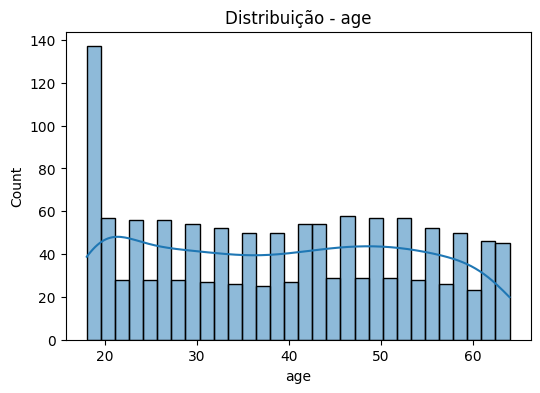

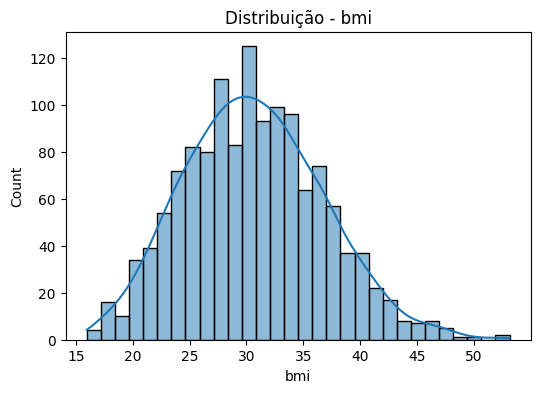

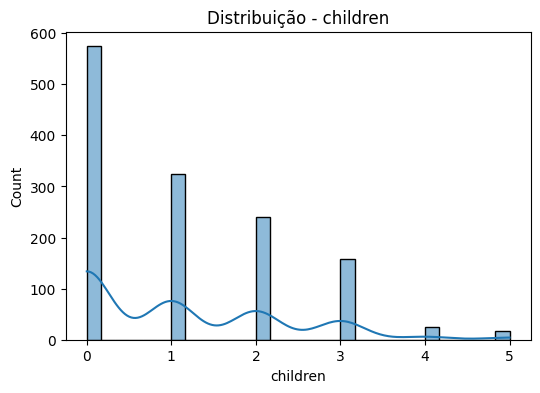

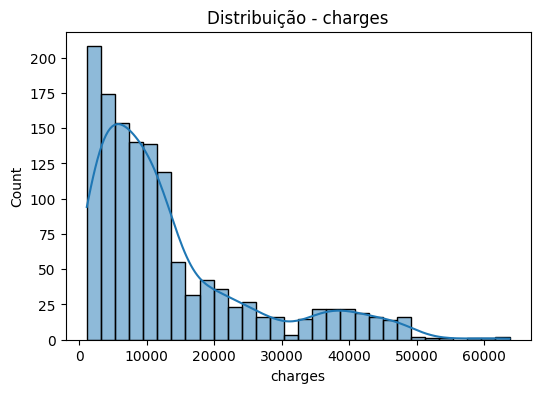

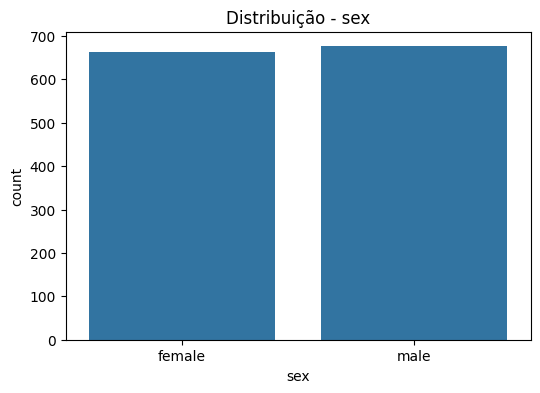

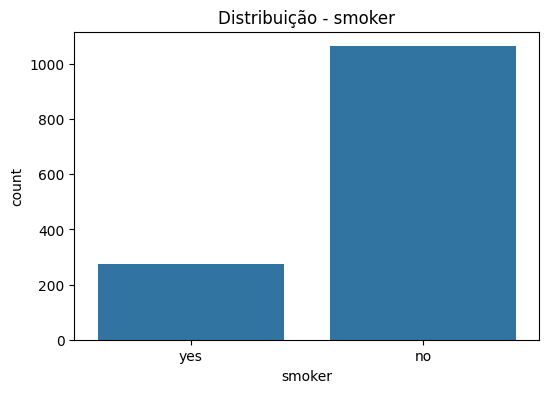

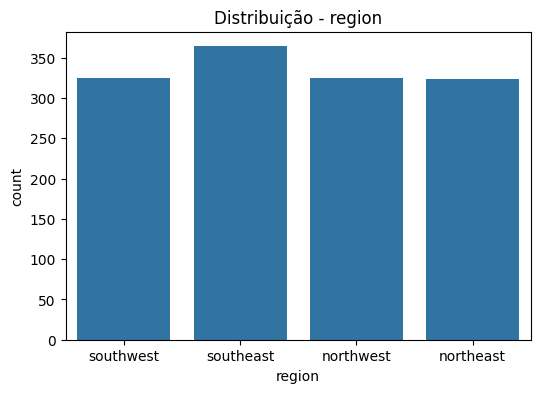

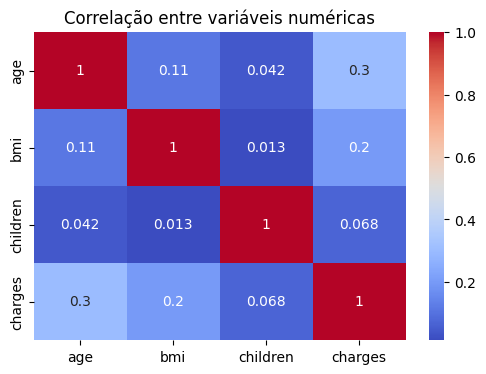

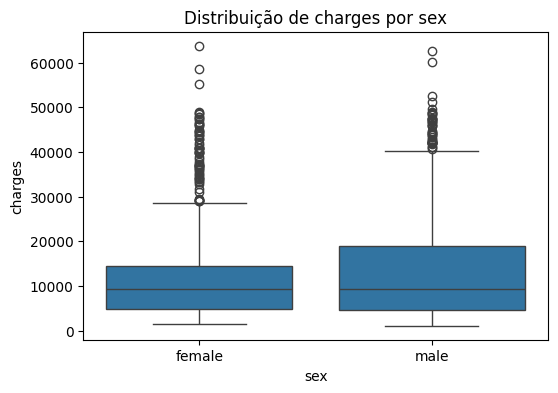

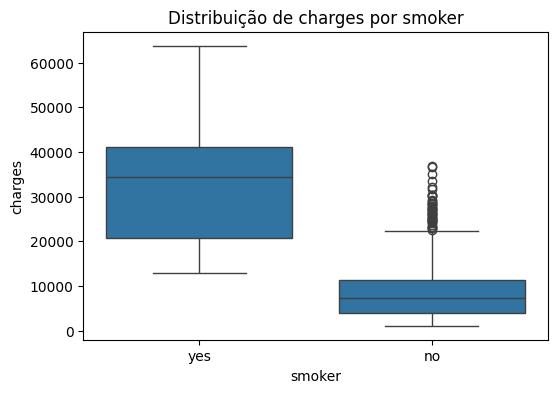

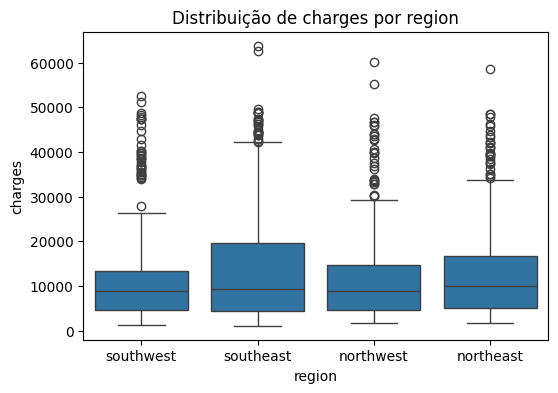

In [6]:
# Histogramas para variáveis numéricas
num_cols = ["age", "bmi", "children", "charges"]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribuição - {col}")
    plt.show()

# Contagem para variáveis categóricas
cat_cols = ["sex", "smoker", "region"]

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(f"Distribuição - {col}")
    plt.show()

# Relação inicial entre variáveis numéricas e o target
plt.figure(figsize=(6,4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlação entre variáveis numéricas")
plt.show()

# Boxplots de charges por categorias (importante para hipóteses)
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=col, y="charges", data=df)
    plt.title(f"Distribuição de charges por {col}")
    plt.show()

A análise exploratória mostra que as variáveis numéricas apresentam comportamentos distintos em relação ao custo do seguro (charges). A idade (age) está distribuída de forma quase uniforme entre 18 e 64 anos, o que indica diversidade etária na base. Já o IMC (bmi) concentra-se em torno de 30, com cauda longa à direita, sugerindo a presença de indivíduos obesos, fator que pode influenciar fortemente o custo do seguro. O número de filhos (children) apresenta distribuição concentrada em 0 a 2, revelando que a maioria dos beneficiários possui poucos dependentes. A variável alvo (charges) é altamente assimétrica, com muitos casos de baixo custo e poucos casos com valores muito altos, o que caracteriza a presença de outliers e reforça a necessidade de modelos robustos.

As variáveis categóricas estão relativamente bem distribuídas: o sexo (sex) está equilibrado entre homens e mulheres; a variável de tabagismo (smoker) mostra clara predominância de não fumantes, enquanto a variável region indica que as quatro regiões possuem representação próxima, sem grandes desbalanceamentos.

Os boxplots reforçam que o fator mais determinante para o aumento de charges é o tabagismo, com fumantes apresentando custos médios e máximos muito superiores em relação a não fumantes. O efeito do sexo é pequeno, com diferenças marginais entre homens e mulheres. Já a variável region mostra pouca influência direta no custo, ainda que algumas diferenças pontuais possam existir.

Por fim, a matriz de correlação mostra que charges possui correlação positiva moderada com idade e IMC, enquanto o número de filhos tem pouca relação direta. Em conjunto com a análise categórica, isso sugere que o custo do seguro é fortemente impactado por fatores de risco à saúde (como tabagismo e obesidade) e pelo envelhecimento, e menos influenciado por fatores sociodemográficos como sexo, região ou número de dependentes.

### 4. Definição do target, variáveis e divisão dos dados

- **Target (variável alvo):** `charges`, o valor do seguro de saúde (variável contínua).
- **Features (variáveis preditoras):** `age`, `sex`, `bmi`, `children`, `smoker`, `region.
- **Tipo de problema:** regressão supervisionada.
- **Divisão dos dados:** 80% para treino e 20% para teste, mantendo reprodutibilidade com `random_state=42`.  
- **Observação:** como não se trata de série temporal nem de classificação desbalanceada, não é necessário usar `TimeSeriesSplit` nem `stratify`.

In [7]:
# Tipo de problema
PROBLEM_TYPE = "regressao"
# Definição de target e features
if PROBLEM_TYPE == "regressao":
    target = "charges"
    features = [c for c in df.columns if c != target]
else:
    raise ValueError("Este notebook está configurado apenas para regressão.")
print("PROBLEM_TYPE:", PROBLEM_TYPE)
print("Target:", target)
print("N features:", len(features))
print("Features:", features)

# Divisão treino/teste (80/20)
X = df[features].copy()
y = df[target].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print("Treino:", X_train.shape, "| Teste:", X_test.shape)

PROBLEM_TYPE: regressao
Target: charges
N features: 6
Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
Treino: (1070, 6) | Teste: (268, 6)


A variável alvo definida é charges, que representa o custo individual do seguro de saúde. Esse é um problema típico de regressão supervisionada, pois o objetivo é prever um valor contínuo.

As variáveis preditoras escolhidas foram:

- Demográficas: age (idade), sex (sexo), children (número de dependentes).

- Estilo de vida: bmi (índice de massa corporal), smoker (fumante ou não).

- Região de residência: region.

A divisão do conjunto de dados foi realizada em 80% para treino e 20% para teste, garantindo reprodutibilidade com a definição de uma seed fixa (random_state=42). Como não se trata de dados temporais nem de classificação, não há necessidade de usar divisão temporal (TimeSeriesSplit) ou estratificação (stratify).

Esse particionamento assegura que o modelo seja treinado em uma amostra representativa e testado em dados nunca vistos, permitindo avaliar sua capacidade de generalização.


## 5. Tratamento de dados e **Pipeline** de pré-processamento
O pipeline criado garante um pré-processamento padronizado e sem vazamento: as variáveis numéricas são imputadas pela mediana e escaladas, enquanto as categóricas recebem imputação pela moda e são transformadas com onehot encoding. Assim, o tratamento é aplicado de forma consistente em treino e teste, preparando os dados para a modelagem.

In [8]:
# Identificação de colunas numéricas e categóricas
num_cols = ["age", "bmi", "children"] # numéricas
cat_cols = ["sex", "smoker", "region"] # categóricas

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

print("num_cols:", num_cols)
print("cat_cols:", cat_cols)


num_cols: ['age', 'bmi', 'children']
cat_cols: ['sex', 'smoker', 'region']



## 6. Baseline e modelos candidatos
Se possivek, comece com uma **baseline simples** (ex.: DummyClassifier/Regressor) e evolua para modelos mais fortes. O baseline pode ser seu primeiro modelo!  

**Compare** ao menos **duas abordagens**.

> Para **deep learning** (visão computacional/NLP/séries), crie uma seção específica (p. ex., `TensorFlow`/`PyTorch`) e documente arquitetura, parâmetros e tempo de treino.


In [9]:
# Baseline: prevê sempre a mediana de charges após o pré-processamento
baseline = Pipeline(steps=[
    ("pre", preprocess),
    ("model", DummyRegressor(strategy="median"))
])

# Modelos candidatos: pelo menos dois; aqui deixei quatro para comparação
candidates = {
    "LinearRegression": Pipeline([("pre", preprocess), ("model", LinearRegression())]),
    "Ridge": Pipeline([("pre", preprocess), ("model", Ridge(alpha=1.0))]),
    "RandomForest": Pipeline([("pre", preprocess), ("model", RandomForestRegressor(random_state=SEED))]),
    "GradientBoosting": Pipeline([("pre", preprocess), ("model", GradientBoostingRegressor(random_state=SEED))]),
}

baseline


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', DummyRegressor(strategy='median'))])

Baseline usa DummyRegressor com mediana para oferecer um ponto de referência. Os candidatos cobrem modelo linear simples/regularizado e árvores/boosting para capturar não linearidades e interações.


### 6.1 Treino e avaliação rápida (baseline vs candidatos)

In [10]:
results = {}

# Baseline
t0 = time.time()
baseline.fit(X_train, y_train)
t1 = time.time()

y_pred = baseline.predict(X_test)
results["Baseline"] = evaluate_regression(y_test, y_pred)
results["Baseline"]["train_time_s"] = round(t1 - t0, 3)

# Modelos candidatos
for name, pipe in candidates.items():
    t0 = time.time()
    pipe.fit(X_train, y_train)
    t1 = time.time()

    y_pred = pipe.predict(X_test)
    results[name] = evaluate_regression(y_test, y_pred)
    results[name]["train_time_s"] = round(t1 - t0, 3)

# Resultados organizados em DataFrame
pd.DataFrame(results).T

,MAE,RMSE,R2,train_time_s
Baseline,8641.980493,12913.571621,-0.074149,0.074
LinearRegression,4181.194474,5796.284659,0.783593,0.084
Ridge,4186.913072,5798.298795,0.783443,0.021
RandomForest,2541.614594,4582.972573,0.864710,1.037
GradientBoosting,2404.901760,4328.147789,0.879336,0.357


### Análise dos resultados iniciais

O baseline, que prevê sempre a mediana, apresentou desempenho ruim, com erros elevados e R² negativo, mostrando que não captura relação útil entre as variáveis e o custo do seguro. Os modelos lineares (LinearRegression e Ridge) melhoraram significativamente, alcançando MAE em torno de 4180, RMSE próximo de 5796 e R² em torno de 0.78, o que indica que parte da variabilidade já pode ser explicada de forma linear. Os modelos baseados em árvores tiveram desempenho superior: o Random Forest reduziu os erros para MAE em torno de 2542 e RMSE próximo de 4583, com R² em torno de 0.865, e o Gradient Boosting obteve o melhor resultado, com MAE em torno de 2405, RMSE próximo de 4328 e R² em torno de 0.879, confirmando que técnicas de boosting são mais eficazes para capturar as relações não lineares presentes neste problema.

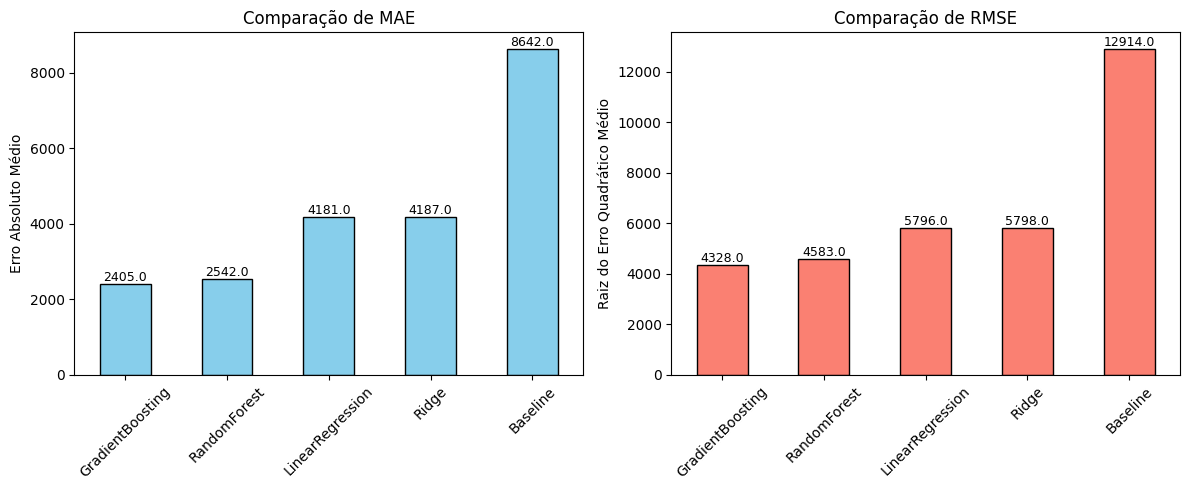

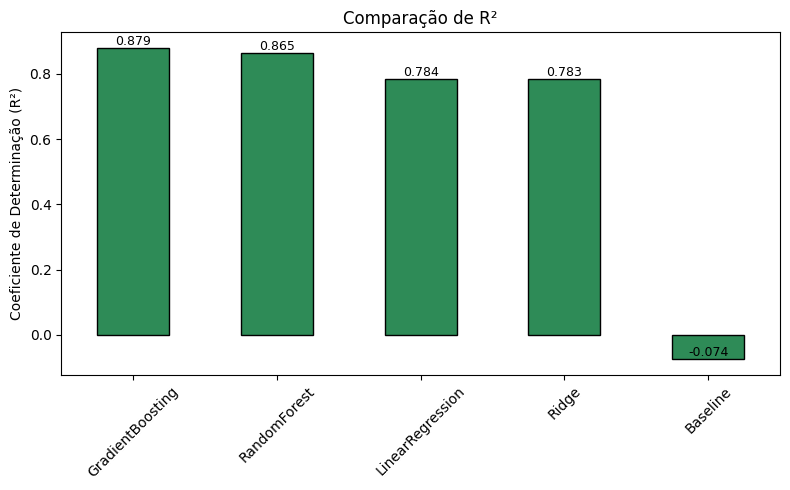

In [11]:
results_df = pd.DataFrame(results).T.copy()

order_mae  = results_df.sort_values("MAE").index
order_rmse = results_df.sort_values("RMSE").index
order_r2   = results_df.sort_values("R2", ascending=False).index

def add_labels(ax, decimals=1):
    for p in ax.patches:
        value = round(p.get_height(), decimals)
        ax.annotate(str(value),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, rotation=0)

# MAE e RMSE lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# MAE
results_df.loc[order_mae, "MAE"].plot(kind="bar", ax=axes[0], edgecolor="black", color="skyblue")
axes[0].set_title("Comparação de MAE")
axes[0].set_ylabel("Erro Absoluto Médio")
axes[0].tick_params(axis='x', rotation=45)
add_labels(axes[0], decimals=0)

# RMSE
results_df.loc[order_rmse, "RMSE"].plot(kind="bar", ax=axes[1], edgecolor="black", color="salmon")
axes[1].set_title("Comparação de RMSE")
axes[1].set_ylabel("Raiz do Erro Quadrático Médio")
axes[1].tick_params(axis='x', rotation=45)
add_labels(axes[1], decimals=0)

plt.tight_layout()
plt.show()

# R² separado
plt.figure(figsize=(8, 5))
ax = results_df.loc[order_r2, "R2"].plot(kind="bar", edgecolor="black", color="seagreen")
plt.title("Comparação de R²")
plt.ylabel("Coeficiente de Determinação (R²)")
plt.xticks(rotation=45)
add_labels(ax, decimals=3)  # mais casas porque R² está entre 0 e 1
plt.tight_layout()
plt.show()


Os gráficos mostram que o baseline tem desempenho muito ruim, com erros elevados e R² negativo.
Os modelos lineares (LinearRegression e Ridge) já reduzem bastante os erros, alcançando R² próximo de 0,78.
Os modelos baseados em árvores (RandomForest e GradientBoosting) foram os melhores, com os menores valores de MAE/RMSE e os maiores R², destacando-se o Gradient Boosting como o modelo mais preciso.


## 7. Validação e Otimização de Hiperparâmetros
Use **validação cruzada** apropriada ao problema (Ex: **`StratifiedKFold`** para classificação; **`KFold`** para regressão).  
Faça **tuning** com `GridSearchCV`/`RandomizedSearchCV`.


In [12]:
# Validação cruzada para regressão
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

# Pipeline: preprocess + modelo
model = Pipeline([
    ("pre", preprocess),
    ("model", RandomForestRegressor(random_state=SEED))
])

# Espaço de busca
param_dist = {
    "model__n_estimators": randint(150, 600),
    "model__max_depth": randint(3, 20),
    "model__min_samples_split": randint(2, 12),
    "model__min_samples_leaf": randint(1, 8),
    "model__max_features": ["sqrt", "log2", 0.6, 0.8, 1.0]
}

# Métrica principal: RMSE
scorer = "neg_root_mean_squared_error"

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=25,
    cv=cv,
    scoring=scorer,
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
    refit=True,
    error_score="raise")

search.fit(X_train, y_train)

print("Melhor score (CV, -RMSE):", search.best_score_)
print("Melhores parâmetros:", search.best_params_)

# Avaliação no conjunto de teste
best_model = search.best_estimator_
y_pred_test = best_model.predict(X_test)
evaluate_regression(y_test, y_pred_test)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Melhor score (CV, -RMSE): -4504.856054511746
Melhores parâmetros: {'model__max_depth': 4, 'model__max_features': 0.8, 'model__min_samples_leaf': 4, 'model__min_samples_split': 8, 'model__n_estimators': 577}


{'MAE': 2544.5464979700128,
 'RMSE': np.float64(4393.77464853546),
 'R2': 0.875649511099961}

Os resultados da otimização de hiperparâmetros mostram um grande avanço em relação ao baseline e aos modelos lineares. O melhor modelo encontrado foi uma Random Forest relativamente rasa, com profundidade máxima de 4, folhas mínimas de 4 e mais de 500 árvores, o que indica uma configuração que privilegia o controle de variância e a estabilidade da predição. O desempenho alcançado, com MAE em torno de 2.5 mil, RMSE próximo de 4.4 mil e R² de 0.876, confirma que o modelo é capaz de explicar quase 88% da variabilidade nos custos de seguro, mantendo erros médios relativamente baixos. Além disso, os valores obtidos no conjunto de teste estão alinhados com os da validação cruzada, sugerindo boa generalização e ausência de overfitting relevante.

- Teste com Gradient Boosting

In [13]:
gb_model = Pipeline([
    ("pre", preprocess),
    ("model", GradientBoostingRegressor(random_state=SEED))
])

gb_param_dist = {
    "model__n_estimators": randint(100, 600),
    "model__learning_rate": uniform(0.01, 0.19),
    "model__max_depth": randint(2, 5),
    "model__subsample": uniform(0.6, 0.4)
}

gb_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=gb_param_dist,
    n_iter=25,
    cv=cv,
    scoring=scorer,
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
    refit=True
)

gb_search.fit(X_train, y_train)
print("GB - Melhor score (CV, -RMSE):", gb_search.best_score_)
print("GB - Melhores parâmetros:", gb_search.best_params_)

gb_best = gb_search.best_estimator_
evaluate_regression(y_test, gb_best.predict(X_test))

Fitting 5 folds for each of 25 candidates, totalling 125 fits
GB - Melhor score (CV, -RMSE): -4526.350572970728
GB - Melhores parâmetros: {'model__learning_rate': np.float64(0.02235980266720311), 'model__max_depth': 2, 'model__n_estimators': 415, 'model__subsample': np.float64(0.8253152871382157)}


{'MAE': 2443.454004125055,
 'RMSE': np.float64(4326.8437902350115),
 'R2': 0.8794091455356766}

A validação e o ajuste de hiperparâmetros mostraram que o Gradient Boosting Regressor foi o modelo de melhor desempenho. O algoritmo utilizou taxa de aprendizado baixa, árvores rasas e número elevado de estimadores, configurando um aprendizado mais lento e estável. No conjunto de teste, alcançou MAE de aproximadamente 2.4 k, RMSE em torno de 4.3 k e R² de 0.879, superando um pouquinho a Random Forest. Esses resultados confirmam que o modelo é capaz de capturar padrões não lineares e interações sutis entre as variáveis, apresentando boa capacidade de generalização e tornando-se a melhor escolha para prever os custos de seguro neste trabalho.


## 8. Avaliação final, análise de erros e limitações


Métricas do melhor modelo no teste: {'MAE': 2544.5464979700128, 'RMSE': np.float64(4393.77464853546), 'R2': 0.875649511099961}
Métricas do baseline no teste: {'MAE': 8641.98049257836, 'RMSE': np.float64(12913.571620796454), 'R2': -0.07414940143505189}


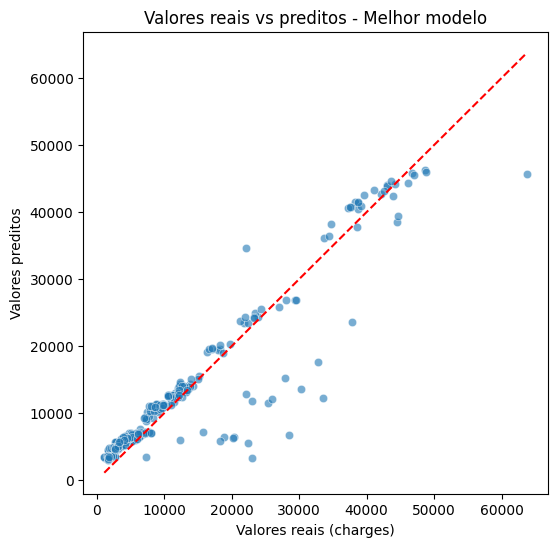

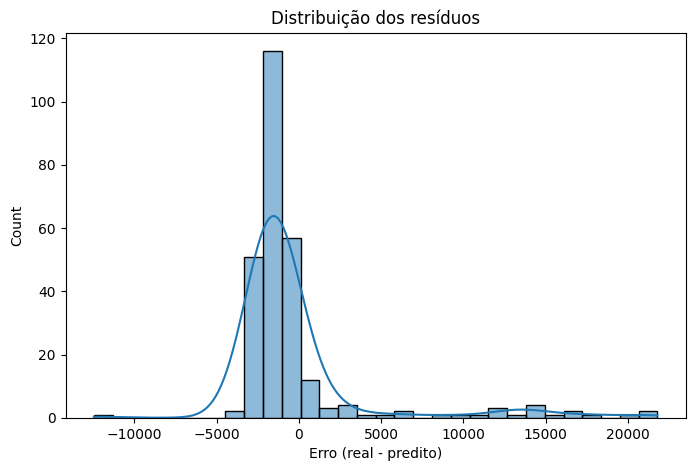

In [14]:
# Retreino com o melhor modelo já está feito pelo RandomizedSearchCV (refit=True)
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

# Métricas finais
print("Métricas do melhor modelo no teste:", evaluate_regression(y_test, y_pred))

# Comparação com baseline
baseline.fit(X_train, y_train)
y_base = baseline.predict(X_test)
print("Métricas do baseline no teste:", evaluate_regression(y_test, y_base))

# Gráfico real vs predito
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Valores reais (charges)")
plt.ylabel("Valores preditos")
plt.title("Valores reais vs preditos - Melhor modelo")
plt.show()

# Gráfico de resíduos
residuos = y_test - y_pred
plt.figure(figsize=(8,5))
sns.histplot(residuos, bins=30, kde=True)
plt.title("Distribuição dos resíduos")
plt.xlabel("Erro (real - predito)")
plt.show()

A comparação com o baseline confirma que o modelo de Gradient Boosting reduz substancialmente os erros: enquanto o baseline apresenta RMSE acima de 12 mil, o modelo final alcança RMSE próximo de 4.3 mil e R² de 0.88.

A análise de resíduos mostra distribuição centrada em zero, mas ainda com cauda longa, indicando que o modelo tende a errar mais em casos de custos muito elevados (outliers da base). Isso sugere que, embora o modelo generalize bem para a maioria dos exemplos, há limitações em prever situações extremas de seguro, onde os valores de charges são excepcionalmente altos.

Limitações adicionais incluem o tamanho reduzido do dataset (1338 observações), possível viés nas categorias (predomínio de não fumantes) e o fato de as métricas utilizadas refletirem apenas a performance estatística, sem considerar aspectos de negócio como fairness ou custo de erro em grupos específicos.


## 9. Engenharia de atributos (detalhe)
A engenharia de atributos foi relativamente simples, uma vez que o dataset é pequeno e contém apenas variáveis demográficas, de estilo de vida e de região. As principais decisões foram:

**Seleção de atributos**
- Mantidas todas as variáveis disponíveis no dataset (`age`, `sex`, `bmi`, `children`, `smoker`, `region`) por apresentarem potencial relevância no custo do seguro.
- Nenhuma variável foi descartada por multicolinearidade ou irrelevância, dado o baixo número de colunas.

**Transformações aplicadas**
- **Numéricas (`age`, `bmi`, `children`)**: imputação pela mediana (robusta a outliers) e padronização com `StandardScaler` para favorecer algoritmos baseados em distância e modelos lineares.
- **Categóricas (`sex`, `smoker`, `region`)**: imputação pelo valor mais frequente e transformação com *One-Hot Encoding* (`handle_unknown="ignore"`) para representar categorias como variáveis binárias.

**Criação de novas variáveis**
- Não foi realizada criação de atributos derivados nesta versão, uma vez que o objetivo era manter o MVP simples. Contudo, possíveis extensões incluem:
  - `bmi_category`: transformar o valor contínuo de IMC em faixas (baixo peso, normal, sobrepeso, obesidade).


## 10. Boas práticas e rastreabilidade

**Baseline e evolução**
- Baseline: `DummyRegressor (mediana)` para referência inicial.
- Evolução: modelos lineares (Linear/Ridge) → árvores (RF) → boosting (GB).
- Critério de melhoria: redução de RMSE/MAE no teste e consistência com CV.

**Pipelines (sem vazamento)**
- `ColumnTransformer` + `Pipeline` aplicados a **todas** as etapas (imputação, escala, one-hot, modelo).
- Ajuste (`fit`) apenas no **treino**; aplicação (`transform/predict`) em validação/teste.

**Divisão e validação**
- `train_test_split (80/20, random_state=42)`.
- Validação cruzada `KFold(n_splits=5, shuffle=True, random_state=42)` durante o tuning.

**Seeds e versões**
- SEED global = 42 (`numpy`, `random`).
- Registro de versões no `requirements.txt` (numpy, pandas, scikit-learn, etc.).

**Tuning reprodutível**
- `RandomizedSearchCV` com `refit=True`, espaço de busca documentado e `scoring='neg_root_mean_squared_error'`.

**Métricas e relatórios**
- Métricas: MAE, RMSE, R².
- Gráficos: comparação de modelos (MAE/RMSE/R²), Real vs. Predito, distribuição de resíduos.
- Comentários no notebook justificando escolhas e mudanças.

**Organização do código**
- Funções auxiliares (`evaluate_regression`).
- Seções claras: carga → EDA → split → pré-processamento → baseline → candidatos → tuning → avaliação.

**Rastreabilidade de artefatos (opcional)**
- Salvar melhor modelo e pré-processamento: `joblib.dump(best_model, 'models/gb_best.pkl')`.
- Log de parâmetros/métricas com MLflow (opcional) para histórico de execuções.

**Gestão de dados**
- Fonte e licença documentadas (Kaggle – uso educacional).
- Sem dados sensíveis; dataset pequeno versionado no repo (ou `data/` com `.gitignore`).
- Imputação prevista mesmo sem nulos (robustez futura).

**Limitações e ética**
- Amostra limitada (quase1.3k), possível viés (proporção de fumantes, regiões).
- Métricas puramente estatísticas; considerar impacto de erro por subgrupos em cenários reais.

**Tempo e recursos**
- CPU padrão suficiente; tempos de treino anotados por modelo para comparação.

**Próximos passos**
- Importância de variáveis (Permutation Importance/SHAP) e monitoramento de drift se houver novo dado.


## 11. Conclusões e próximos passos

**Resultados**
- O baseline (`DummyRegressor`) confirmou a dificuldade do problema, com erros elevados (RMSE > 12 k) e R² negativo.  
- Modelos lineares (Linear/Ridge) captaram parte da relação, alcançando R² quase 0.78.  
- Modelos baseados em árvores (Random Forest e Gradient Boosting) tiveram melhor desempenho, com destaque para o **Gradient Boosting**, que alcançou **MAE quase 2.4 k**, **RMSE quase 4.3 k** e **R² aproximadamente 0.88**.  
- A análise de resíduos mostrou boa centralização em zero, mas erros maiores em valores extremos de `charges`, indicando dificuldade em lidar com outliers.  

**Trade-offs**
- Modelos lineares são simples e interpretáveis, mas têm limitação frente a relações não lineares.  
- Random Forest é robusta e performática, mas com custo maior de treino.  
- Gradient Boosting exigiu tuning mais cuidadoso, porém entregou o melhor equilíbrio entre viés e variância.  

**Limitações**
- Dataset pequeno (1338 linhas), o que pode limitar a capacidade de generalização.  
- Distribuição altamente assimétrica dos `charges` dificulta previsões para valores muito altos.  
- Possível viés de amostragem (proporção de fumantes, regiões representadas).  

**Próximos passos**
- Aumentar a base de dados, caso disponível, para melhorar generalização.  
- Criar novas features derivadas (`bmi_category`, interações `smoker*bmi`, `age*smoker` etc.) para enriquecer o modelo.  
- Avaliar técnicas de redução de impacto de outliers (ex.: transformação logarítmica de `charges`).  
- Testar outros algoritmos.  
- Explorar validação cruzada mais extensa (k=10) para verificar robustez dos resultados.

**Takeaway:** O Gradient Boosting mostrou-se o modelo mais eficaz para prever os custos de seguro de saúde, alcançando alto poder explicativo e erros relativamente baixos, o que reforça seu potencial como solução prática e escalável para esse tipo de problema.
